# D1_nose_covered — 무라벨(라벨링 없이) 획득

MediaPipe FaceMesh 검출률과 CLIP 제로샷 프롬프트 앙상블을 결합한 2-신호 의사라벨링. 코가 이불에 덮이면 face mesh 검출이 실패하는 경향(face_frac 하락)을 쓰되, 랜드마크 부재만으로는 '엎드림/화면 밖'과 '가림'을 구분할 수 없으므로 CLIP 제로샷(가림/보임/엎드림·빈침대 3개 프롬프트 그룹 소프트맥스)으로 이를 분리한다. 최종 점수는 nose_covered_score = p_covered × (1 − face_frac)이며, 이진 라벨 임계값 0.25는 검증 셀의 분포를 보고 조정한다.

In [1]:
# 설치 셀 — 처음 실행 후 protobuf/numpy 경고가 나오면: 런타임 → 세션 다시 시작 → 이어서 실행
!pip install -q mediapipe==0.10.14 transformers av decord
!pip -q uninstall -y tensorflow  # mediapipe 0.10.14(protobuf4)와 TF(protobuf5) 충돌 방지 — 이 노트북은 TF 미사용

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 10.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.


In [2]:
# 공통 설정 — Drive 마운트 + 경로 + manifest
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd

BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, 'mp4 폴더 없음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), 'manifest.csv 를 BASE 에 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
man = pd.read_csv(BASE/'manifest.csv')
print('clips:', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 / manifest:', len(man))

Mounted at /content/drive
clips: /content/drive/MyDrive/BabyMon/dataset/clips 24080 개 / manifest: 24080


## D1_nose_covered — 코 가림(이불) 무라벨 의사라벨링

**접근**: 서로 약점을 보완하는 두 신호의 앙상블.

1. **MediaPipe FaceMesh 가시성** — 코·하관이 이불에 덮이면 face mesh 검출 자체가 실패하는 경향이 있다. 샘플 프레임 중 mesh 검출 비율 `face_frac`을 계산하고, 검출된 프레임에서는 코 ROI 라플라시안 분산(`nose_lapvar`, 하관 질감 보조 신호)도 기록한다. 240x136 저해상도이므로 3배 업스케일 후 검출한다.
2. **CLIP 제로샷** — 랜드마크 부재만으로는 '엎드림/얼굴 밖'과 '이불 가림'을 구분할 수 없다. 프레임 전체에 대해 `covered`(얼굴이 이불에 덮인 아기) / `visible`(얼굴이 잘 보이는 아기) / `away`(엎드림·등돌림·빈 침대) 3그룹 프롬프트 소프트맥스로 `p_covered`를 얻어 이를 분리한다.

**최종 점수**: `nose_covered_score = p_covered × (1 − face_frac)` — CLIP의 가림 증거와 랜드마크 부재가 동시에 성립할 때만 높아진다. 이진 라벨 임계값 0.25는 검증 셀 히스토그램을 보고 조정한다. (저해상도 영아 얼굴에서 FaceMesh가 가림 없이도 실패할 수 있으나, 그 경우 점수는 `p_covered`가 지배하므로 여전히 판별력이 유지된다.)

**참고 문헌**
- Under the Cover Infant Pose Estimation using Multimodal Data (WACV 2023): https://arxiv.org/abs/2210.00662
- An Intelligent Baby Monitor with Automatic Sleeping Posture Detection and Notification (MDPI AI, 2021): https://www.mdpi.com/2673-2688/2/2/18
- Neonatal Face and Facial Landmark Detection from Video Recordings (2023): https://arxiv.org/pdf/2302.04341
- When Face Recognition Meets Occlusion: A New Benchmark (ICASSP 2021): https://arxiv.org/pdf/2103.02805
- MediaPipe Face Landmarker 문서: https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker

In [3]:
# 모델 초기화: MediaPipe FaceMesh + CLIP 제로샷
import numpy as np, pandas as pd, cv2, torch
import mediapipe as mp
from transformers import CLIPModel, CLIPProcessor

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_FRAMES = 12   # 클립당 샘플 프레임 수
UPSCALE = 3     # 240x136 -> 720x408 (FaceMesh 용)

face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=True, max_num_faces=1,
    refine_landmarks=False, min_detection_confidence=0.3)

clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE).eval()
clip_proc = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

PROMPT_GROUPS = {
  'covered': ["a baby in a crib with its nose and mouth covered by a blanket",
              "an infant's face covered by bedding",
              "a blanket pulled up over a sleeping baby's face"],
  'visible': ["a baby in a crib with its face fully visible",
              "an infant's uncovered face with visible nose and mouth",
              "a sleeping baby with a clearly visible face"],
  'away':    ["a baby sleeping face down on a mattress",
              "a baby facing away from the camera",
              "an empty baby crib with blankets"]}
PROMPTS = sum(PROMPT_GROUPS.values(), [])
GROUP_SLICES, _i = {}, 0
for g, ps in PROMPT_GROUPS.items():
    GROUP_SLICES[g] = slice(_i, _i + len(ps)); _i += len(ps)

with torch.no_grad():
    tok = clip_proc(text=PROMPTS, return_tensors='pt', padding=True).to(DEVICE)
    TXT = clip_model.text_projection(clip_model.text_model(**tok).pooler_output)
    TXT = TXT / TXT.norm(dim=-1, keepdim=True)
print('init ok:', DEVICE, tuple(TXT.shape))

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

init ok: cuda (9, 512)


In [4]:
# 클립 1개 처리 -> dict
from decord import VideoReader, cpu

def _nose_lapvar(res, up_gray, W, H):
    # 코끝(landmark 1) 주변 ROI 질감(라플라시안 분산) — 하관 텍스처 보조 신호
    lm = res.multi_face_landmarks[0].landmark
    nx, ny = lm[1].x * W, lm[1].y * H
    eyed = np.hypot((lm[263].x - lm[33].x) * W, (lm[263].y - lm[33].y) * H)
    r = max(int(eyed * 0.35), 4)
    roi = up_gray[max(0, int(ny - r)):int(ny + r), max(0, int(nx - r)):int(nx + r)]
    return float(cv2.Laplacian(roi, cv2.CV_64F).var()) if roi.size else np.nan

def process_clip(path):
    vr = VideoReader(str(path), ctx=cpu(0))
    idx = np.linspace(0, len(vr) - 1, min(N_FRAMES, len(vr))).astype(int)
    frames = vr.get_batch(idx).asnumpy()  # (N,H,W,3) RGB uint8
    found, lapvars = [], []
    for fr in frames:
        up = cv2.resize(fr, None, fx=UPSCALE, fy=UPSCALE, interpolation=cv2.INTER_CUBIC)
        res = face_mesh.process(up)  # RGB 입력
        ok = res.multi_face_landmarks is not None
        found.append(ok)
        if ok:
            try:  # ROI 좌표 계산 실패 대비 (API/경계 불확실성)
                g = cv2.cvtColor(up, cv2.COLOR_RGB2GRAY)
                lapvars.append(_nose_lapvar(res, g, up.shape[1], up.shape[0]))
            except Exception:
                pass
    with torch.no_grad():
        im = clip_proc(images=list(frames), return_tensors='pt').to(DEVICE)
        feat = clip_model.visual_projection(clip_model.vision_model(pixel_values=im['pixel_values']).pooler_output)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        probs = (feat @ TXT.T * 100).softmax(-1).mean(0).cpu().numpy()
    p = {g: float(probs[s].sum()) for g, s in GROUP_SLICES.items()}
    face_frac = float(np.mean(found))
    score = p['covered'] * (1 - face_frac)
    return {'n_frames': int(len(frames)), 'face_frac': face_frac,
            'nose_lapvar': float(np.nanmedian(lapvars)) if lapvars else np.nan,
            'p_covered': p['covered'], 'p_visible': p['visible'], 'p_away': p['away'],
            'nose_covered_score': float(score),
            'label_nose_covered': int(score >= 0.25)}  # 임계값은 검증 셀 보고 조정

In [5]:
# 배치 루프 — 증분 저장(재실행 시 이미 처리한 file 건너뜀)
OUT = BASE / 'auto_D1_nose_covered.csv'
N_CLIPS = 1000
COLS = ['file', 'n_frames', 'face_frac', 'nose_lapvar', 'p_covered', 'p_visible',
        'p_away', 'nose_covered_score', 'label_nose_covered', 'error']

done = set(pd.read_csv(OUT)['file']) if OUT.exists() else set()
sub = man.sample(min(N_CLIPS, len(man)), random_state=42)
todo = [f for f in sub['file'] if f not in done]
print(f'대상 {len(sub)}개 중 미처리 {len(todo)}개')

buf, n_done = [], 0
for f in todo:
    try:
        row = {'file': f, **process_clip(CLIPS / f), 'error': ''}
    except Exception as e:
        row = {'file': f, 'error': str(e)[:100]}
    buf.append(row); n_done += 1
    if n_done % 50 == 0 or n_done == len(todo):
        pd.DataFrame(buf).reindex(columns=COLS).to_csv(
            OUT, mode='a', header=not OUT.exists(), index=False)
        buf = []
        print(f'{n_done}/{len(todo)} 저장 완료 -> {OUT.name}')
print('배치 완료')

대상 1000개 중 미처리 1000개


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


50/1000 저장 완료 -> auto_D1_nose_covered.csv
100/1000 저장 완료 -> auto_D1_nose_covered.csv
150/1000 저장 완료 -> auto_D1_nose_covered.csv
200/1000 저장 완료 -> auto_D1_nose_covered.csv
250/1000 저장 완료 -> auto_D1_nose_covered.csv
300/1000 저장 완료 -> auto_D1_nose_covered.csv
350/1000 저장 완료 -> auto_D1_nose_covered.csv
400/1000 저장 완료 -> auto_D1_nose_covered.csv
450/1000 저장 완료 -> auto_D1_nose_covered.csv
500/1000 저장 완료 -> auto_D1_nose_covered.csv
550/1000 저장 완료 -> auto_D1_nose_covered.csv
600/1000 저장 완료 -> auto_D1_nose_covered.csv
650/1000 저장 완료 -> auto_D1_nose_covered.csv
700/1000 저장 완료 -> auto_D1_nose_covered.csv
750/1000 저장 완료 -> auto_D1_nose_covered.csv
800/1000 저장 완료 -> auto_D1_nose_covered.csv
850/1000 저장 완료 -> auto_D1_nose_covered.csv
900/1000 저장 완료 -> auto_D1_nose_covered.csv
950/1000 저장 완료 -> auto_D1_nose_covered.csv
1000/1000 저장 완료 -> auto_D1_nose_covered.csv
배치 완료


성공 1000 / 전체 1000, 양성(label=1) 647개


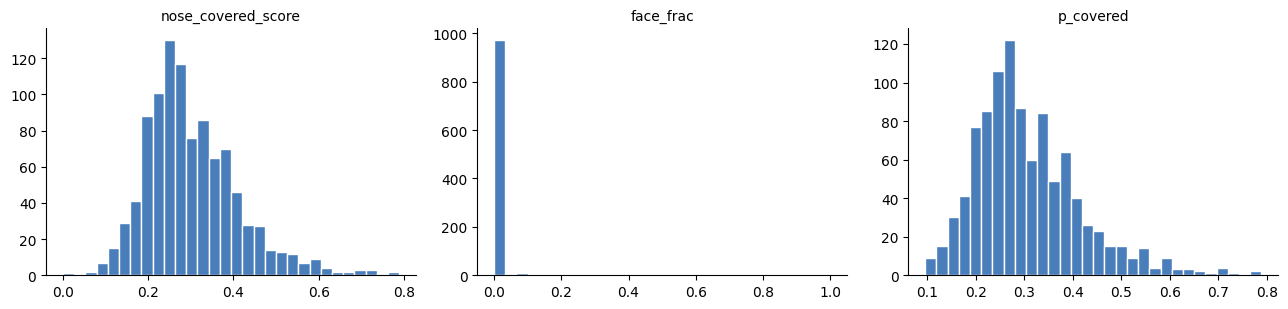

/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.


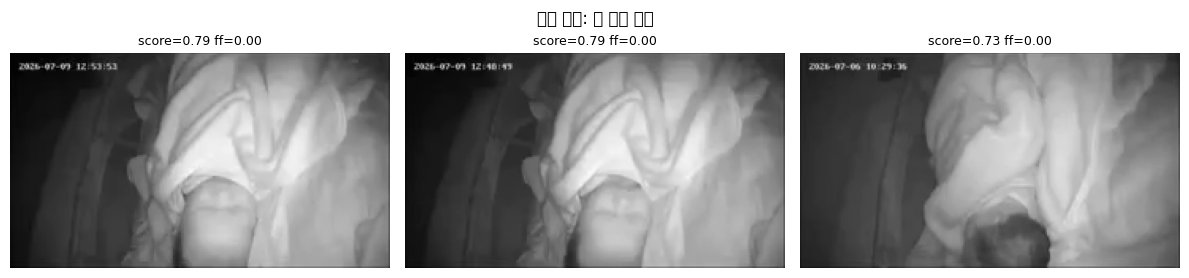

/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 50620 (\N{HANGUL SYLLABLE EOL}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 44404 (\N{HANGUL SYLLABLE GUL}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 51096 (\N{HANGUL SYLLABLE JAL}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_860/3544339289.py:27: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) 

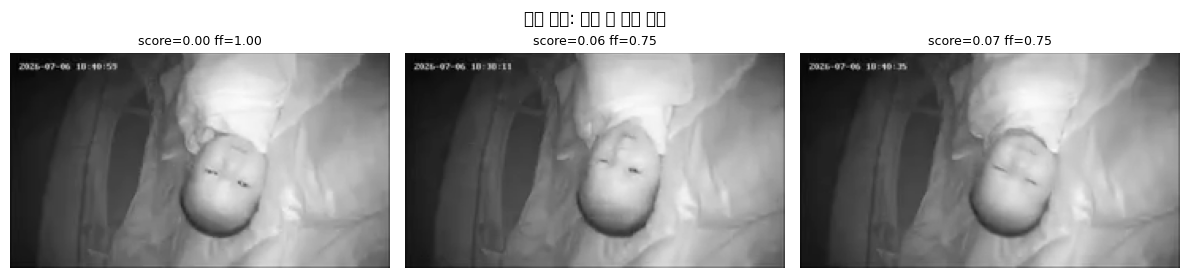

In [6]:
# 검증: 점수 분포 + 극단 사례 프레임 확인
import matplotlib.pyplot as plt
from decord import VideoReader, cpu

res = pd.read_csv(OUT).drop_duplicates('file')
ok = res[res['error'].isna() | (res['error'] == '')].copy()
print(f"성공 {len(ok)} / 전체 {len(res)}, 양성(label=1) {int(ok['label_nose_covered'].sum())}개")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, ['nose_covered_score', 'face_frac', 'p_covered']):
    ax.hist(ok[col].dropna(), bins=30, color='#4A7EBB', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

def show_examples(df, title, k=3):
    rows = df.head(k)
    fig, axes = plt.subplots(1, k, figsize=(4 * k, 2.8))
    for ax, (_, r) in zip(np.atleast_1d(axes), rows.iterrows()):
        try:
            vr = VideoReader(str(CLIPS / r['file']), ctx=cpu(0))
            ax.imshow(vr[len(vr) // 2].asnumpy())
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:40], ha='center')
        ax.set_title(f"score={r['nose_covered_score']:.2f} ff={r['face_frac']:.2f}", fontsize=9)
        ax.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_examples(ok.sort_values('nose_covered_score', ascending=False), '점수 상위: 코 가림 후보')
show_examples(ok.sort_values('nose_covered_score'), '점수 하위: 얼굴 잘 보임 후보')
# 상위 예시가 실제 '이불 가림'이 아니라 '엎드림'이면 away 프롬프트를 보강하거나 임계값 상향